In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","steel.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
Ge_decay = np.array([10.3670, 1.2990, 1.1432, 0.1595, 0.1035])
Ge_I = np.array([87.58, 10.44, 0.05, 1.92, 0.01])

(-1.0, 11.0)

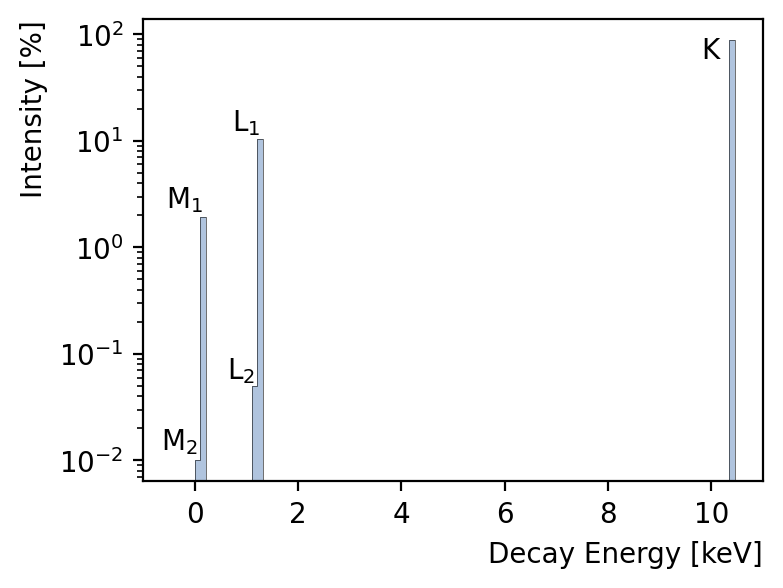

In [3]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(Ge_decay, bins=np.linspace(0, 11, 101), weights = Ge_I, color = 'lightsteelblue')
plt.hist(Ge_decay, bins=np.linspace(0, 11, 101), weights = Ge_I, histtype='step', color = 'black', lw = 0.2)

plt.text(10, 7e1, r'$\mathrm{K}$', ha='center', va='center', family='serif', fontsize = 10)
plt.text(1, 1.5e1, r'$\mathrm{L_1}$', ha='center', va='center', family='serif', fontsize = 10)
plt.text(0.9, 0.7e-1, r'$\mathrm{L_2}$', ha='center', va='center', family='serif', fontsize = 10)
plt.text(-0.2, 2.8e0, r'$\mathrm{M_1}$', ha='center', va='center', family='serif', fontsize = 10)
plt.text(-0.3, 1.5e-2, r'$\mathrm{M_2}$', ha='center', va='center', family='serif', fontsize = 10)

plt.yscale('log')
plt.xlabel(r"Decay Energy [keV]", loc = 'right')
plt.ylabel("Intensity [%]", loc = 'top')
plt.xlim(-1, 11)

[CDMS ELOG](https://scdms.slac.stanford.edu/elog/CUTE+Detectors/66): The neutron source was last deployed Dec. 12th at 15:22 to Dec. 13th at 08:55 (17 hours, 33 minutes). It doesn't seem that any other source exposures occurred before the following Ge series were taken.

In [4]:
# Time frame of source exposure in Unix time
source_start = 1702412520
source_end = 1702475700

[CUTE at SNOLAB](https://arxiv.org/pdf/2310.07930): The activity of the neutron source is 37.5 kBq.\
This gives us a total of $2.369 \times 10^9$ decays during the exposure period.

Need a simulation of Cf-252 source in the CUTE geometry to tell us how many neutrons are captured in the detector.

In [5]:
#ProdTag = 'CUTE_T3_Calibration_v3.0.0_V05-03_P0.3.3'
ProdTag = 'CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2.'

In [6]:
filepath = np.sort(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/CDMS/CUTE/R37/Processed/Tests/{ProdTag}/Submerged/{ProdTag}_232312??_??????.root')) # Cedar

In [7]:
## Identify series list and pull data from data catalog
## Z1 held at 50V bias.

#series_list=['23231216_013604', '23231216_043946', '23231216_100125', '23231216_145300', '23231216_182937', '23231216_194929', '23231216_211119', '23231216_233807', 
             #'23231217_135018', '23231217_171613', '23231217_212512', '23231218_093255', '23231218_152721', '23231218_190035', '23231218_223530', '23231219_034952', 
             #'23231219_110331', '23231219_184002', '23231216_115012', '23231220_012745'] # Ge calibration  

#dc = CDMSDataCatalog().findData(
#    Facility    = "CUTE",
#    nFridgeRun  = 37,
#    Series      = series_list,
#    ProdTag     = "CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2.",
#    nMergeLevel = 1,
#    dofetch     = True
#)

#filepath = [x.filePath for x in dc]

In [8]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [9]:
## Apply some basic data quality filters and get the RQs you're interested in
logfile = '"cute_tower3testing.log"'
df = df.Define("LEDLogFile", logfile) 
df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
df = df.Filter("!LEDOn")
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])

In [10]:
RQs = (["PTOFamps","PTOFchisqLF", "PTOFdelay", "EventNumber"] + 
       ['P' + label + 'S' + sequence + 'OFamps' for sequence in ['1', '2'] for label in ['A', 'B', 'C', 'D', 'E', 'F']])
df_rqs = df_filtered.AsNumpy(RQs)

Text(0, 1, 'PTOFchisqLF')

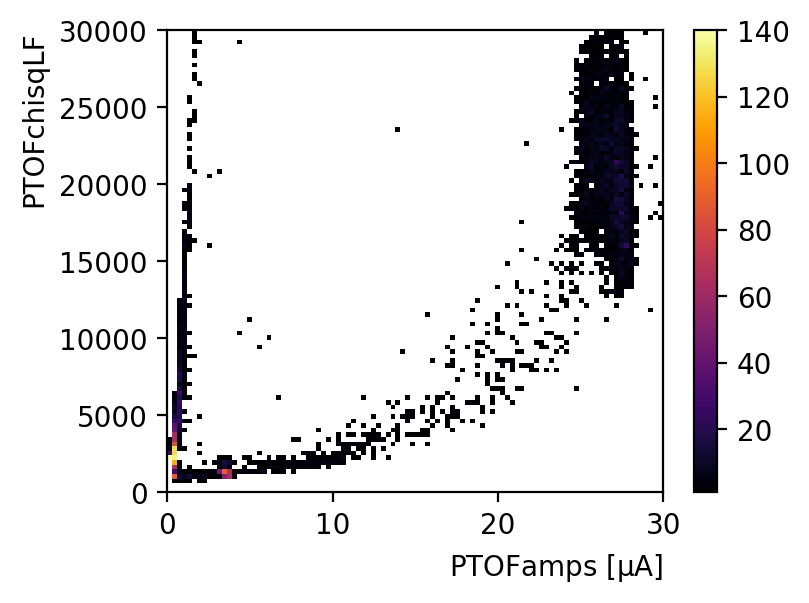

In [11]:
## Have a look at the PTOFamps vs chisq to make more cuts

plt.figure(figsize=(4,3), dpi=200)
plt.hist2d(df_rqs["PTOFamps"]*1e6,df_rqs["PTOFchisqLF"],bins=(np.linspace(0, 30, 101),np.linspace(0, 30e3, 101)),cmin=1e-7,cmax=200)
plt.colorbar()
plt.xlim(0,30)

plt.xlabel(r"PTOFamps [$\mathrm{\mu A}$]")
plt.ylabel("PTOFchisqLF")

Text(0, 1, 'Count / $\\mathrm{\\mu A}$')

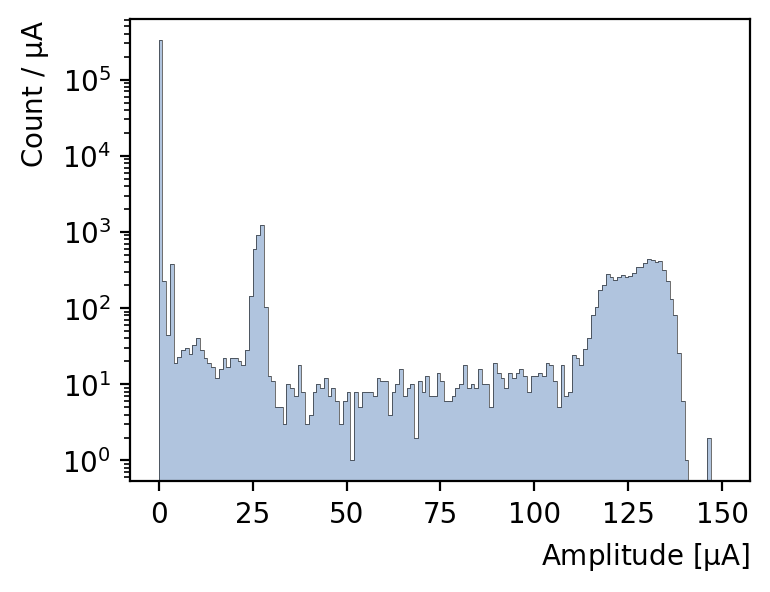

In [12]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 150, 151), color = 'lightsteelblue')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 150, 151), histtype='step', color = 'black', lw = 0.2)
plt.yscale('log')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / $\mathrm{\mu A}$")

Text(0, 1, 'Count / (0.3 $\\mathrm{\\mu A}$)')

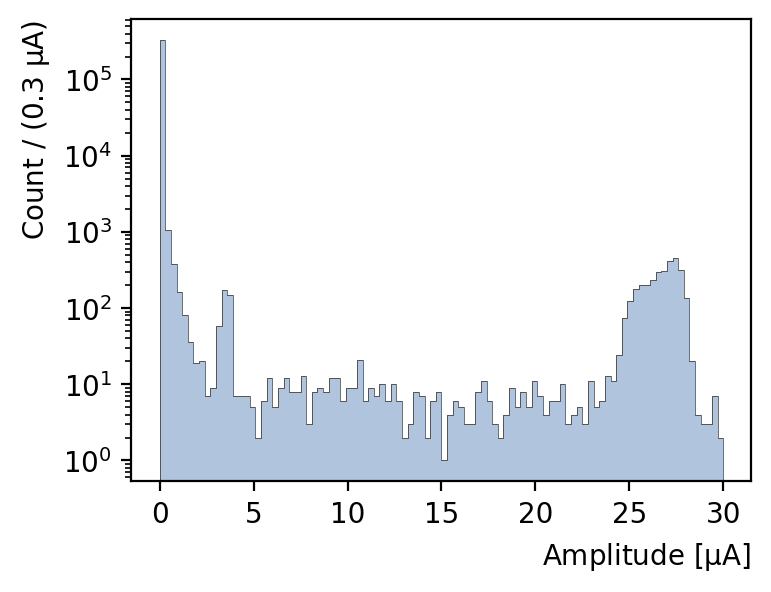

In [13]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 30, 101), color = 'lightsteelblue')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 30, 101), histtype='step', color = 'black', lw = 0.2)
plt.yscale('log')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.3 $\mathrm{\mu A}$)")

Text(0, 1, 'Count / (0.125 $\\mathrm{\\mu A}$)')

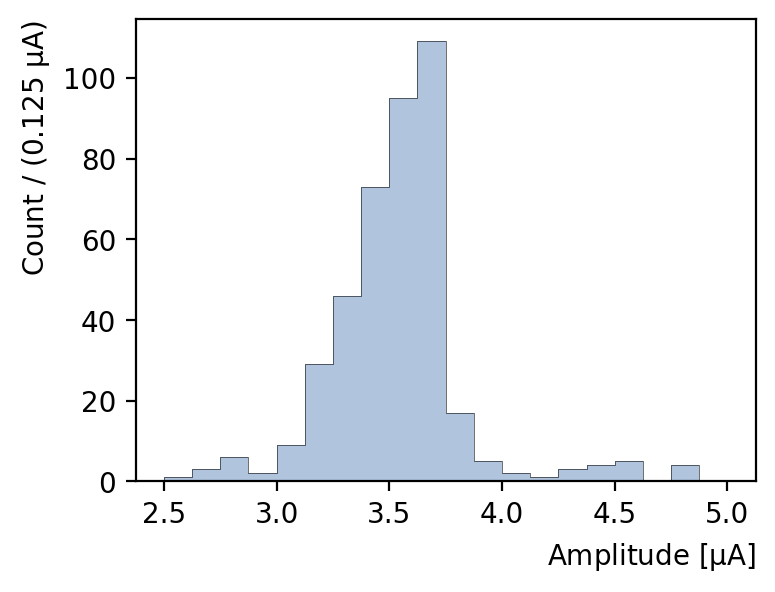

In [14]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(2.5, 5, 21), color = 'lightsteelblue')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(2.5, 5, 21), histtype='step', color = 'black', lw = 0.2)
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.125 $\mathrm{\mu A}$)")
#plt.ylim(0, 500)

Text(0, 1, 'Count / (0.2 $\\mathrm{\\mu A}$)')

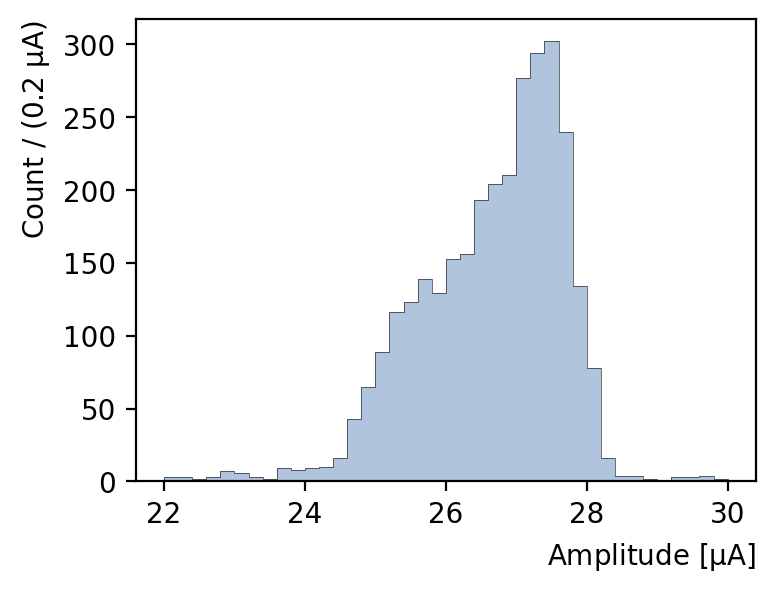

In [15]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(22, 30, 41), color = 'lightsteelblue')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(22, 30, 41), histtype='step', color = 'black', lw = 0.2)
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.2 $\mathrm{\mu A}$)")
#plt.ylim(0, 500)

In [16]:
L_peak_data = df_rqs['PTOFamps'][(df_rqs['PTOFamps'] >= 2.5e-6) & (df_rqs['PTOFamps'] <= 5e-6)] * 1e6
K_peak_data = df_rqs['PTOFamps'][(df_rqs['PTOFamps'] >= 22e-6) & (df_rqs['PTOFamps'] <= 30e-6)] * 1e6

# Let's fit the k-peak with two Gaussians and a flat background
$$
model = c_1 \cdot Gauss_1(\mu_1,\sigma_1) + c_2 \cdot Gauss_2(\mu_2,\sigma_2) +  (1-c_1- c_2) \cdot Uniform
$$

In [17]:
# make a frame
def make_frame(obs, *objects):
    frame = obs.frame()
    for obj in objects:
        obj.plotOn(frame)
    return frame

# draw a frame
def make_plot(frame):
    c = ROOT.TCanvas()
    frame.Draw()
    c.Draw()
    # need this for the plot not to be removed!
    ROOT.SetOwnership( c, False )

In [18]:
# Observable
x = ROOT.RooRealVar("x", "x", 22, 30)

# Parameters
mean_1 = ROOT.RooRealVar("#mu1", "#mu", 26, 22, 30)
sigma_g1 = ROOT.RooRealVar("#sigma1", "#sigma", 1, 0.1, 10)
mean_2 = ROOT.RooRealVar("#mu2", "#mu", 27.5, 22, 30)
sigma_g2 = ROOT.RooRealVar("#sigma2", "#sigma", 0.5, 0.1, 10)

# Distributions
g1 = ROOT.RooGaussian("g1", "g1", x, mean_1, sigma_g1)
g2 = ROOT.RooGaussian("g2", "g2", x, mean_2, sigma_g2)
flat = ROOT.RooUniform("flat", "flat", x)

# Weight of distributions
frac1 = ROOT.RooRealVar("c1", "#c", 0.5, 0.0, 1.0)
frac2 = ROOT.RooRealVar("c2", "#c", 0.2, 0.0, 1.0)

# Convert numpy array into RooFit object
pdf = ROOT.RooAddPdf("model", "model", [g1, g2, flat], [frac1, frac2])
# 
data = ROOT.RooDataSet.from_numpy({"x": K_peak_data},[x],name='2_gauss',title='2_gauss')

 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         2.60000e+01  8.00000e-01    2.20000e+01  3.00000e+01
     2 #mu2         2.75000e+01  8.00000e-01    2.20000e+01  3.00000e+01
     3 #sigma1      1.00000e+00  4.50000e-01    1.00000e-01  1.00000e+01
     4 #sigma2      5.00000e-01  2.00000e-01    1.00000e-01  1.00000e+01
     5 c1           5.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     6 c2           2.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 **********
 **    6 **MIGRAD        3000           1
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 START MIGRAD MINI

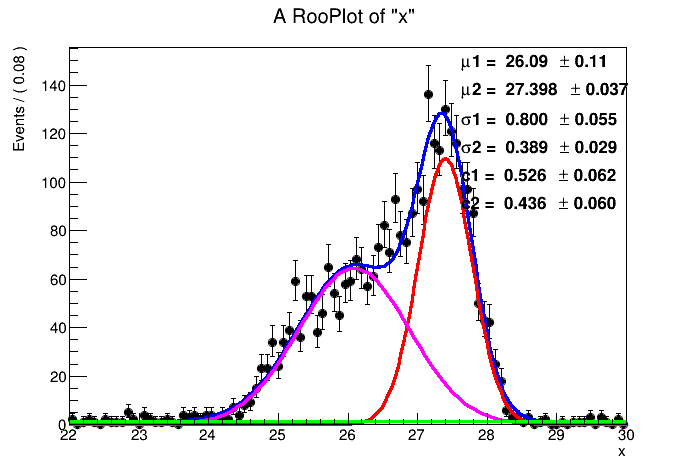

In [19]:
nll = pdf.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()


frame = make_frame(x,data,pdf)

# We can also plot components of the model. No need to bother with normalization.
pdf.plotOn(frame, 
           Components=f'g2', # choose a component of the model to draw using the name
           LineColor=ROOT.kRed, 
          )

pdf.plotOn(frame, 
           Components=f'g1', # choose a component of the model to draw using the name
           LineColor=ROOT.kMagenta)

pdf.plotOn(frame, 
           Components=f'flat', # choose a component of the model to draw using the name
           LineColor=ROOT.kGreen)


pdf.paramOn(frame)
make_plot(frame)

In [40]:
x = np.linspace(22, 30, 101)
mu1, mu2 = 26.09, 27.398
sigma1, sigma2 = 0.8, 0.389
c1, c2 = 0.526, 0.436

gauss1 = 1 / np.sqrt(2 * np.pi * sigma1**2) * np.exp( -(x - mu1)**2 / (2 * sigma1**2) )
gauss2 = 1 / np.sqrt(2 * np.pi * sigma2**2) * np.exp( -(x - mu2)**2 / (2 * sigma2**2) )
flat = np.array([1.0 / 8 for i in range(len(x))])

PDF = c1 * gauss1 + c2 * gauss2 + (1 - c1 - c2) * flat

(0.0, 0.65)

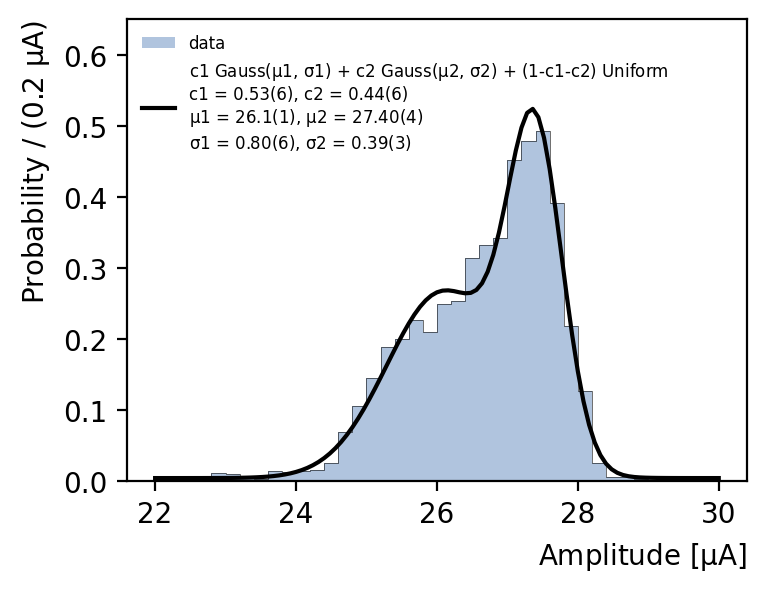

In [53]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(22, 30, 41), color = 'lightsteelblue', density=True, label = 'data')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(22, 30, 41), histtype='step', color = 'black', lw = 0.2, density=True)
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Probability / (0.2 $\mathrm{\mu A}$)")

plt.plot(x, PDF, color = 'black', label = r'c1 Gauss($\mathrm{\mu 1}$, $\mathrm{\sigma1}$) + c2 Gauss($\mathrm{\mu 2}$, $\mathrm{\sigma2}$) + (1-c1-c2) Uniform' + 
                                    '\n' +r'c1 = 0.53(6), c2 = 0.44(6)'
                                    '\n' + r'$\mathrm{\mu1}$ = 26.1(1), $\mathrm{\mu2}$ = 27.40(4)'
                                    '\n' + r'$\mathrm{\sigma1}$ = 0.80(6), $\mathrm{\sigma2}$ = 0.39(3)')

plt.legend(fontsize = 6, loc = 'upper left')

plt.ylim(0, 0.65)

# Let's fit the L-peak with a skewed Gaussian and a flat background
$$
model = \lambda_1 \cdot Johnson(\mu_1,\sigma_1,) + (1-\lambda_1) \cdot Uniform
$$

In [91]:
# Observable
x = ROOT.RooRealVar("x", "x", 2.5, 5)

# Parameters
mean_1 = ROOT.RooRealVar("#mu1", "#mu", 3.5, 2, 6)
lambda_1 = ROOT.RooRealVar("#lambda1", "#lambda", 1, 0.1, 4)
delta_1 = ROOT.RooRealVar("#delta1", "#delta", 4, 0.1, 5)
gamma_1 = ROOT.RooRealVar("#gamma1", "#gamma", 3, 0.1, 5)

# Distributions
j1 = ROOT.RooJohnson("j1", "j1", x, mean_1, lambda_1, gamma_1, delta_1)
flat = ROOT.RooUniform("flat", "flat", x)

# Weights of distributions
frac1 = ROOT.RooRealVar("c1", "c", 0.5, 0.0, 1.0)

# Weighted sum of distributions
pdf = ROOT.RooAddPdf("model", "model", [j1, flat], [frac1])
# Convert numpy array into RooFit object
data = ROOT.RooDataSet.from_numpy({"x": L_peak_data},[x],name='1_Johnson',title='1_Johnson')

 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #delta1      4.00000e+00  4.90000e-01    1.00000e-01  5.00000e+00
     2 #gamma1      3.00000e+00  4.90000e-01    1.00000e-01  5.00000e+00
     3 #lambda1     1.00000e+00  3.90000e-01    1.00000e-01  4.00000e+00
     4 #mu1         3.50000e+00  4.00000e-01    2.00000e+00  6.00000e+00
     5 c1           5.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 **********
 **    6 **MIGRAD        2500           1
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 START MIGRAD MINIMIZATION.  STRATEGY  1.  CONVERGENCE WHEN EDM .LT. 1.00e-03
 FCN=284.382 

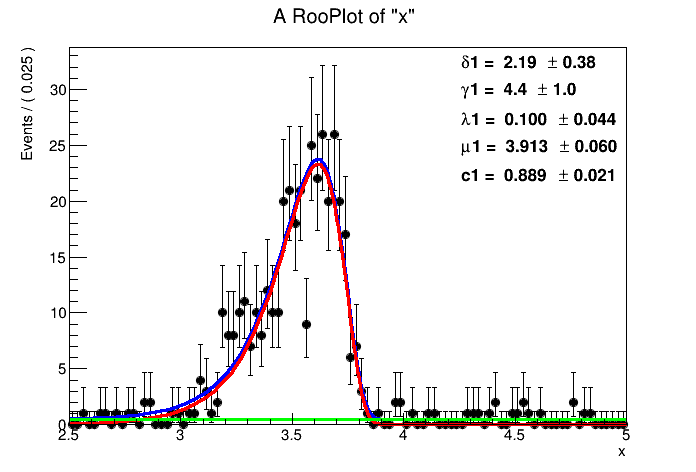

In [92]:
nll = pdf.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()


frame = make_frame(x,data,pdf)

# We can also plot components of the model. No need to bother with normalization.
pdf.plotOn(frame, 
           Components=f'j1', # choose a component of the model to draw using the name
           LineColor=ROOT.kRed, 
          )

pdf.plotOn(frame, 
           Components=f'flat', # choose a component of the model to draw using the name
           LineColor=ROOT.kGreen)


pdf.paramOn(frame)
make_plot(frame)

In [95]:
x = np.linspace(2.5, 5, 101)
delta1 = 2.19
gamma1 = 4.4
lambda1 = 0.1
mu1 = 3.913
c1 = 0.889

Johnson1 = delta1 / (lambda1 * np.sqrt(2 * np.pi)) * 1/np.sqrt(1 + ( (x - mu1) / lambda1 )**2 ) * np.exp( -1/2 * (gamma1 + delta1 * np.arcsinh( (x - mu1) / lambda1) )**2 )
flat = np.array([1.0 / 2.5 for i in range(len(x))])

PDF = c1 * Johnson1 + (1 - c1) * flat

(0.0, 2.75)

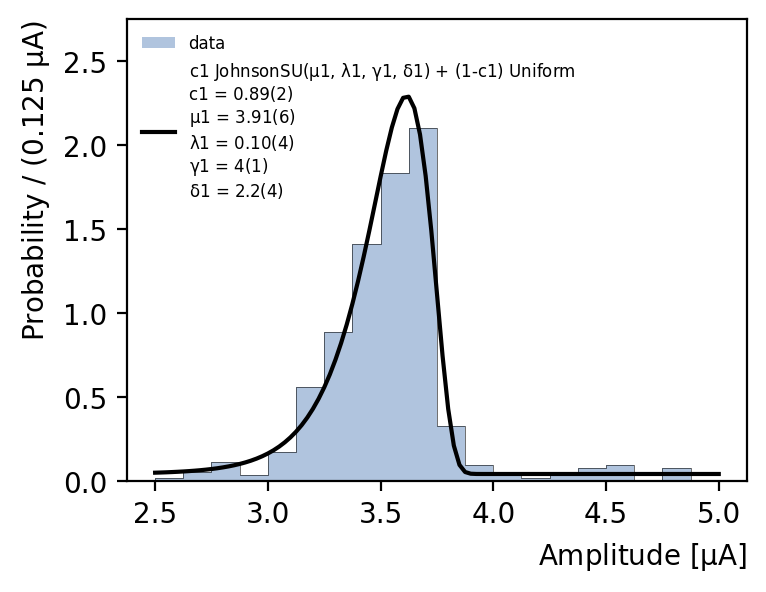

In [97]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(2.5, 5, 21), color = 'lightsteelblue', density=True, label = 'data')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(2.5, 5, 21), histtype='step', color = 'black', lw = 0.2, density=True)
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Probability / (0.125 $\mathrm{\mu A}$)")


plt.plot(x, PDF, color = 'black', label = r'c1 JohnsonSU($\mathrm{\mu 1}$, $\mathrm{\lambda1}$, $\mathrm{\gamma1}$, $\mathrm{\delta1}$) + (1-c1) Uniform' + 
                                    '\n' +r'c1 = 0.89(2)'
                                    '\n' + r'$\mathrm{\mu1}$ = 3.91(6)'
                                    '\n' + r'$\mathrm{\lambda1}$ = 0.10(4)'
                                    '\n' + r'$\mathrm{\gamma1}$ = 4(1)'
                                    '\n' + r'$\mathrm{\delta1}$ = 2.2(4)')

plt.legend(fontsize = 6, loc = 'upper left')

plt.ylim(0, 2.75)